In [1]:
import pytorch as torch
import numpy as np
import random
import math
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc  
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import log_loss
import math
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#创建用户类
class Client():
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.w_cur=[]
        self.number=len(y)

NUM_USER=30

def softmax(x):
    ex = np.exp(x)
    sum_ex = np.sum( np.exp(x))
    return ex/sum_ex

def generate_synthetic(alpha, beta, iid):

    dimension = 60
    NUM_CLASS = 10

    samples_per_user = np.random.lognormal(4, 2, (NUM_USER)).astype(int) + 50
    
    num_samples = np.sum(samples_per_user)

    X_split = [[] for _ in range(NUM_USER)]
    y_split = [[] for _ in range(NUM_USER)]


    #### define some eprior ####
    mean_W = np.random.normal(0, alpha, NUM_USER)
    mean_b = mean_W
    B = np.random.normal(0, beta, NUM_USER)
    mean_x = np.zeros((NUM_USER, dimension))

    diagonal = np.zeros(dimension)
    for j in range(dimension):
        diagonal[j] = np.power((j+1), -1.2)
    cov_x = np.diag(diagonal)

    for i in range(NUM_USER):
        mean_x[i] = np.random.normal(B[i], 1, dimension)
        


    for i in range(NUM_USER):

        W = np.random.normal(mean_W[i], 1, (dimension, NUM_CLASS))
        b = np.random.normal(mean_b[i], 1,  NUM_CLASS)

        xx = np.random.multivariate_normal(mean_x[i], cov_x, samples_per_user[i])
        yy = np.zeros(samples_per_user[i])

        for j in range(samples_per_user[i]):
            tmp = np.dot(xx[j], W) + b
            yy[j] = np.argmax(softmax(tmp))

        X_split[i] = xx.tolist()
        y_split[i] = yy.tolist()

        


    return X_split, y_split


TEST_USER=10
def generate_test_synthetic(alpha, beta):

    dimension = 60
    NUM_CLASS = 10

    samples_per_user = np.random.lognormal(4, 2, (TEST_USER)).astype(int) + 50
    
    num_samples = np.sum(samples_per_user)

    X_split = [[] for _ in range(TEST_USER)]
    y_split = [[] for _ in range(TEST_USER)]


    #### define some eprior ####
    mean_W = np.random.normal(0, alpha,TEST_USER)
    mean_b = mean_W
    B = np.random.normal(0, beta, TEST_USER)
    mean_x = np.zeros((TEST_USER, dimension))

    diagonal = np.zeros(dimension)
    for j in range(dimension):
        diagonal[j] = np.power((j+1), -1.2)
    cov_x = np.diag(diagonal)

    for i in range(TEST_USER):
        mean_x[i] = np.random.normal(B[i], 1, dimension)
        


    for i in range(NUM_USER):

        W = np.random.normal(mean_W[i], 1, (dimension, NUM_CLASS))
        b = np.random.normal(mean_b[i], 1,  NUM_CLASS)

        xx = np.random.multivariate_normal(mean_x[i], cov_x, samples_per_user[i])
        yy = np.zeros(samples_per_user[i])

        for j in range(samples_per_user[i]):
            tmp = np.dot(xx[j], W) + b
            yy[j] = np.argmax(softmax(tmp))

        X_split[i] = xx.tolist()
        y_split[i] = yy.tolist()
    return X_split, y_split

In [2]:

class Softmax(object):

    def __init__(self,weights,yita=0,miu=0,step=20):
        self.learning_step = 0.001           # 学习速率
        self.max_iteration = step             # 最大迭代次数
        self.k = 10        #分类类别数
        self.w = weights   #定义初始参数（帽子矩阵，W加上偏置项）
        self.miu=miu
        self.yita=yita
        
    def cal_e(self,x,l):
      
        theta_l = self.w[l]
        product = np.dot(theta_l,x)

        return math.exp(product)

    def cal_probability(self,x,j):

        molecule = self.cal_e(x,j)
        denominator = sum([self.cal_e(x,i) for i in range(self.k)])#相当于一共有十个类别

        return molecule/denominator

    def cal_loss(self,x,y,w0):
        loss=0
        for j in range(self.k):
            for i in range(0,len(y)):
                first = int(y[i]==j)                           # 计算示性函数
                second = self.cal_probability(x[i],j)
                loss+=(-first*np.log(second))
            if self.miu>0:
                loss+=self.miu*0.5*np.linalg.norm(w0[j]-self.w[j])**2
        return loss/len(y)
        
    def cal_partial_derivative(self,x,y,j):
        gx=0
        for i in range(0,len(y)):
            first = int(y[i]==j)                           # 计算示性函数
            second = self.cal_probability(x[i],j)          # 计算后面那个概率
            gx=gx-x[i]*(first-second)
        #print(gx/len(y))
        return gx/len(y)

    def predict_(self, x):
        result = np.dot(self.w,x)
        row, column = result.shape

        # 找最大值所在的列
        _positon = np.argmax(result)
        m, n = divmod(_positon, column)

        return m

    def train(self,data,Class,batchsize):
        data_num=len(Class)
        batch_num=data_num//batchsize 
        w0=self.w
        for i in range(self.max_iteration):
            row_indice=np.random.permutation(data_num)
            for h in range(batch_num):
                # 随机选择
                s = row_indice[h*batchsize:(h+1)*batchsize]
                    # 得到该样本的特征向量和标记
                x = np.array(data)[s]
                y=np.array(Class)[s]
                

                derivatives = [self.cal_partial_derivative(x,y,j) for j in range(self.k)]
            
            for j in range(self.k):
                self.w[j] =self.w[j]- self.learning_step * derivatives[j]
                
        return self.w
    
    def prox_train(self,data,Class,batchsize):
        data_num=len(Class)
        batch_num=data_num//batchsize 
        
        w0 = self.w
        for i in range(self.max_iteration):
            row_indice=np.random.permutation(data_num)
          
            for h in range(batch_num):
                # 随机选择
                s = row_indice[h*batchsize:(h+1)*batchsize]
                    # 得到该样本的特征向量和标记
                x = np.array(data)[s]
                y=np.array(Class)[s]
                

                derivatives = [self.cal_partial_derivative(x,y,j) for j in range(self.k)]
            
            for j in range(self.k):
                self.w[j] -= (self.learning_step * derivatives[j]+np.array(self.miu*(self.w[j]-w0[j])))
                
           
                
        return self.w
    
#     def prior_train(self,data,Class,batchsize):
#         data_num=len(Class)
#         batch_num=data_num//batchsize 
#         new_loss = self.cal_loss(data,Class)
#         w0=self.w
#         for i in range(self.max_iteration):
#             row_indice=np.random.permutation(data_num)
#             loss = new_loss
#             for h in range(batch_num):
#                 # 随机选择
#                 s = row_indice[h*batchsize:(h+1)*batchsize]
#                     # 得到该样本的特征向量和标记
#                 x = data[s]
#                 y=Class[s]
#                 x = list(x)
#                 x.append(1.0)
#                 x = np.array(x)

#                 derivatives = [self.cal_partial_derivative(x,y,j) for j in range(self.k)]
            
#             for j in range(self.k):
#                 self.w[j] -= self.learning_step * derivatives[j]
                
#             new_loss = self.cal_loss(data,Class)
#             if abs(loss-new_loss) < 0.0001:
#                 break  
                
#         return self.w    ##这里的先验信息的逻辑还没有想明白

    def predict(self,features):
        labels = []
        for feature in features:
            x = list(feature)
            x.append(1)

            x = np.matrix(x)
            x = np.transpose(x)

            labels.append(self.predict_(x))
        return labels



In [3]:
# self.k = len(set(labels))
# self.w = np.zeros((self.k,len(features[0])+1))

def Global(rounds,data, Class,batchsize=10):
    global_w=np.zeros((10,61))
    training_loss=[]
   
    for i in range(0,rounds):
        p = Softmax(global_w)
        global_w=p.train(data,Class,batchsize)
        global_loss=p.cal_loss(data,Class,global_w)
        training_loss.append(global_loss)   
    return global_w,training_loss
    
    
    
    
def FedAvg(rounds,client_list,batchsize=10):
    w_total_cur=np.zeros((10,61))
    training_loss=[]
   
    for i in range(0,rounds):
        np.random.seed(i)
        selected_clients=np.random.choice(client_list, select_clients, replace=False)
        active_clients=np.random.choice(selected_clients, round(select_clients*(1-straggler_rate)), replace=False)
        sample_num=0
        w0=w_total_cur
        w_total_cur=0
        for c in active_clients:
            p=Softmax(w0)
            c.w_cur=p.train(c.x, c.y,batchsize)
            sample_num+=c.number
            w_total_cur+=c.w_cur*c.number
        w_total_cur= w_total_cur/sample_num
        
        total_p=Softmax(w_total_cur)
        avg_loss=total_p.cal_loss(x_global,y_global,w_total_cur)
        training_loss.append(avg_loss)       
    return w_total_cur,training_loss

def FedProx(rounds,client_list,batchsize=10):
    miu=0
    count_miu_decrease=0
    training_loss=[]
    w_total_cur=np.zeros((10,61))


   
    for i in range(0,rounds):
        np.random.seed(i)
        selected_clients=np.random.choice(client_list, select_clients, replace=False)
        active_clients=np.random.choice(selected_clients, round(select_clients*(1-straggler_rate)), replace=False)
        sample_num=0
        w0=w_total_cur
        w_total_cur=0
        for c in selected_clients:
            if c in active_clients: 
                p=Softmax(w0,miu=miu)
                c.w_cur=p.prox_train(c.x, c.y,batchsize)
                sample_num+=c.number
                w_total_cur+=c.w_cur*c.number     
            else:
                step=np.random.randint(1,20)
                p=Softmax(w_total_cur,miu=miu,step=step)
                c.w_cur=p.prox_train(c.x, c.y,batchsize)
                sample_num+=c.number
                w_total_cur+=c.w_cur*c.number
                
        w_total_cur= w_total_cur/sample_num
        
       
        total_p=Softmax(w_total_cur,miu=miu)
        prox_loss=total_p.cal_loss(x_global,y_global,w_total_cur)
        if(i>0):
            if(training_loss[i-1]>=prox_loss):
                count_miu_decrease+=1
            if(training_loss[i-1]<prox_loss):
                miu+=0.1
                count_miu_decrease=0
        if(count_miu_decrease>=5 and miu>0):
            miu-=0.1
            count_miu_decrease=0
        training_loss.append(prox_loss)
        
    return w_total_cur,training_loss


# def FedPrior(rounds,client_list,dim,yita,batchsize=4):
#     w_total_cur=np.zeros((dim,1))
#     training_loss=[]
#     accuracy_1=[]
#     accuracy_2=[]
   
#     for i in range(0,rounds):
#         np.random.seed(i)
#         selected_clients=np.random.choice(client_list, round(clients_num*select_rate), replace=False)
#         active_clients=np.random.choice(selected_clients, round(clients_num*select_rate*(1-straggler_rate)), replace=False)
#         sample_num=0
#         w0=w_total_cur
#         w_total_cur=0
#         for c in active_clients:
#             c.w_cur=grad_descent_prior(c.x, c.y,w0,yita,batchsize)
#             sample_num+=c.number
#             w_total_cur+=c.w_cur*c.number
#         w_total_cur= w_total_cur/sample_num
        
        
#         prior_loss=loss_funtion_avg(x_global,y_global, w_total_cur)/len(y_global)
#         training_loss.append(prior_loss)
        
#         train_accuracy=0
#         y_train=sigmoid(x_global*w_total_cur)
#         for i in range(len(y_global)):
#             if(y_train[i]<=0.5 and y_global[i]==0):
#                 train_accuracy=train_accuracy+1
#             if(y_train[i]>0.5 and y_global[i]==1):
#                 train_accuracy=train_accuracy+1 
#         train_accuracy=train_accuracy/len(y_global)
#         accuracy_1.append(train_accuracy)
# #预测准确率
#         accuracy=0
#         y_pred=sigmoid(test_x*w_total_cur)
#         for i in range(len(test_y)):
#             if(y_pred[i]<=0.5 and test_y[i]==0):
#                 accuracy=accuracy+1
#             if(y_pred[i]>0.5 and test_y[i]==1):
#                 accuracy=accuracy+1
#         accuracy=accuracy/len(test_y)
#         accuracy_2.append(accuracy)
#     return w_total_cur,accuracy_1,accuracy_2,training_loss

# def PriorProx(rounds,client_list,dim,yita,batchsize=4):
#     training_loss=[]
#     w_total_cur=np.zeros((dim,1))    
#     accuracy_1=[]
#     accuracy_2=[]
   
#     for i in range(0,rounds):
#         np.random.seed(i)
#         selected_clients=np.random.choice(client_list, round(clients_num*select_rate), replace=False)
#         active_clients=np.random.choice(selected_clients, round(clients_num*select_rate*(1-straggler_rate)), replace=False)
#         sample_num=0
#         w0=w_total_cur
#         w_total_cur=0
#         for c in selected_clients:
#             if c in active_clients: 
#                 c.w_cur=grad_descent_prior(c.x, c.y,w0,yita,batchsize)
#                 sample_num+=c.number
#                 w_total_cur+=c.w_cur*c.number     
#             else:
#                 step=np.random.randint(1,20)
#                 c.w_cur=grad_descent_prior(c.x, c.y,w0,yita,batchsize,step)
#                 sample_num+=c.number
#                 w_total_cur+=c.w_cur*c.number
                
#         w_total_cur= w_total_cur/sample_num
        
        
#         pp_loss=loss_funtion_avg(x_global,y_global, w_total_cur)/len(y_global)
#         training_loss.append(pp_loss)
        
#         train_accuracy=0
#         y_train=sigmoid(x_global*w_total_cur)
#         for i in range(len(y_global)):
#             if(y_train[i]<=0.5 and y_global[i]==0):
#                 train_accuracy=train_accuracy+1
#             if(y_train[i]>0.5 and y_global[i]==1):
#                 train_accuracy=train_accuracy+1 
#         train_accuracy=train_accuracy/len(y_global)
#         accuracy_1.append(train_accuracy)
# #预测准确率
#         accuracy=0
#         y_pred=sigmoid(test_x*w_total_cur)
#         for i in range(len(test_y)):
#             if(y_pred[i]<=0.5 and test_y[i]==0):
#                 accuracy=accuracy+1
#             if(y_pred[i]>0.5 and test_y[i]==1):
#                 accuracy=accuracy+1
#         accuracy=accuracy/len(test_y)
#         accuracy_2.append(accuracy)
#     return w_total_cur,accuracy_1,accuracy_2,training_loss

# Figure1

## 0% stragglers

In [5]:
rounds=10
straggler_rate=0
select_clients=10
clients_num=30
batchsize=4
beta=1
alpha=1

In [6]:
#产生数据
X, y = generate_synthetic(alpha=alpha, beta=beta, iid=0) 

In [7]:
client_list=[]
for i in range(0,clients_num):
    x1=X[i]
    y1=y[i]
    b=np.ones(len(y1))
    x1=np.c_[x1,b]
    client1=Client(x1,y1)
    client_list.append(client1)
    
x_global=client_list[0].x
y_global=client_list[0].y
for i in range(1,clients_num):
    x_global=np.vstack((x_global,client_list[i].x))
    y_global=np.hstack((y_global,client_list[i].y))



In [8]:
global_wloss0=Global(rounds,x_global,y_global,batchsize)
avg_w,loss1=FedAvg(rounds,client_list,batchsize)
prox_w,loss2=FedProx(rounds,client_list,batchsize)

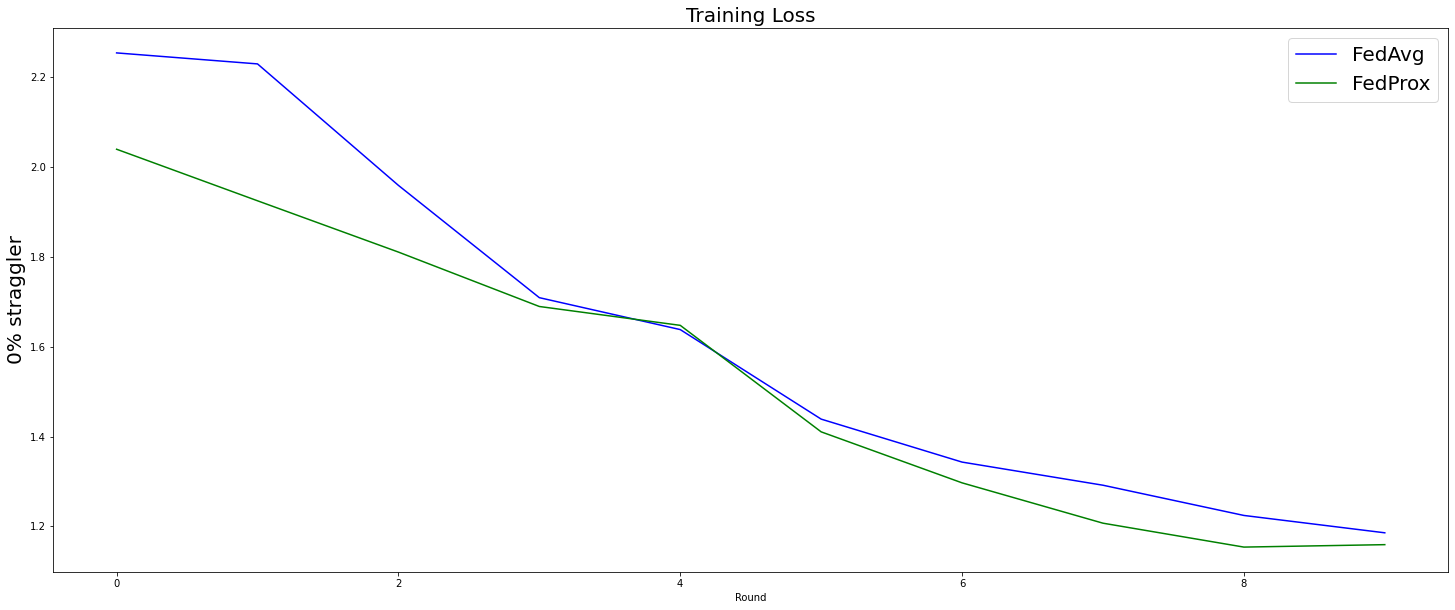

In [9]:
plt.figure(figsize=(25,10))
#plt.plot(np.squeeze(loss0),color='red')
plt.plot(np.squeeze(loss1),color='blue')
plt.plot(np.squeeze(loss2),color='green')
plt.xlabel('Round')
plt.ylabel('0% straggler',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['FedAvg','FedProx'],loc="upper right",fontsize=20)

## 50% stragglers

In [26]:
straggler_rate=0.5
avg_w_5,avg_train_5,avg_test_5,loss1_5=FedAvg(rounds,client_list,dim,batchsize)
prox_w_5,prox_train_5,prox_test_5,loss2_5=FedProx(rounds,client_list,dim,batchsize)
prior_w_5,prior_train_5,prior_test_5,loss3_5=FedPrior(rounds,client_list,dim,0.1,batchsize)
pp_w_5,pp_train_5,pp_test_5,loss4_5=PriorProx(rounds,client_list,dim,0.1,batchsize)

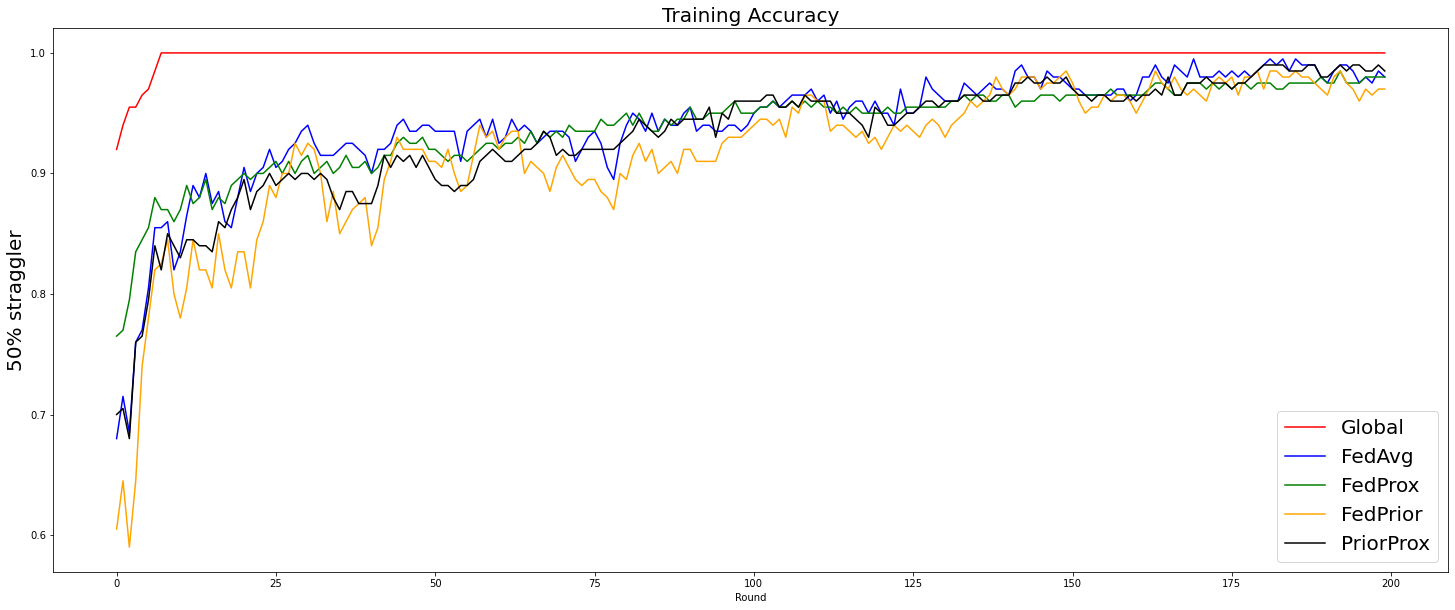

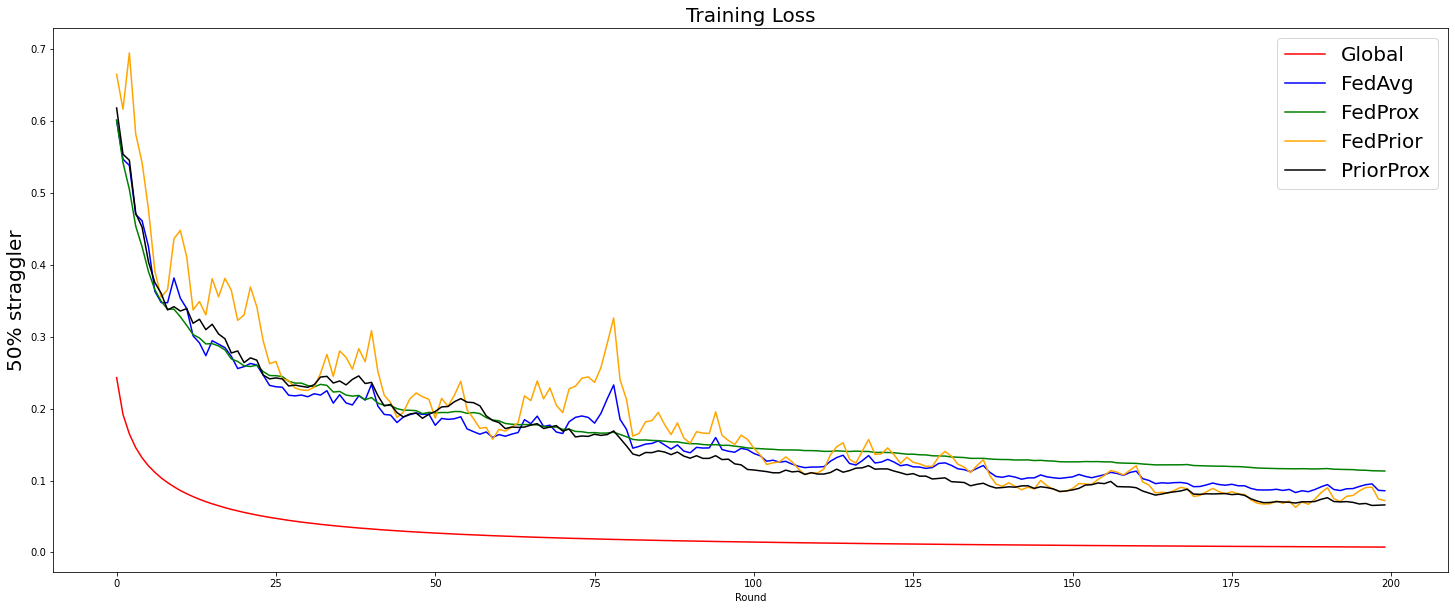

In [27]:
plt.figure(figsize=(25,10))
plt.plot(global_train,color='red')
plt.plot(avg_train_5,color='blue')
plt.plot(prox_train_5,color='green')
plt.plot(prior_train_5,color='orange')
plt.plot(pp_train_5,color='black')
plt.xlabel('Round')
plt.ylabel('50% straggler',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))
#plt.ylim((-0.1,50))
plt.plot(np.squeeze(loss0),color='red')
plt.plot(np.squeeze(loss1_5),color='blue')
plt.plot(np.squeeze(loss2_5),color='green')
plt.plot(np.squeeze(loss3_5),color='orange')
plt.plot(np.squeeze(loss4_5),color='black')
plt.xlabel('Round')
plt.ylabel('50% straggler',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

## 90% stragglers

In [28]:
straggler_rate=0.9
avg_w_9,avg_train_9,avg_test_9,loss1_9=FedAvg(rounds,client_list,dim,batchsize)
prox_w_9,prox_train_9,prox_test_9,loss2_9=FedProx(rounds,client_list,dim,batchsize)
prior_w_9,prior_train_9,prior_test_9,loss3_9=FedPrior(rounds,client_list,dim,0.1,batchsize)
pp_w_9,pp_train_9,pp_test_9,loss4_9=PriorProx(rounds,client_list,dim,0.1,batchsize)

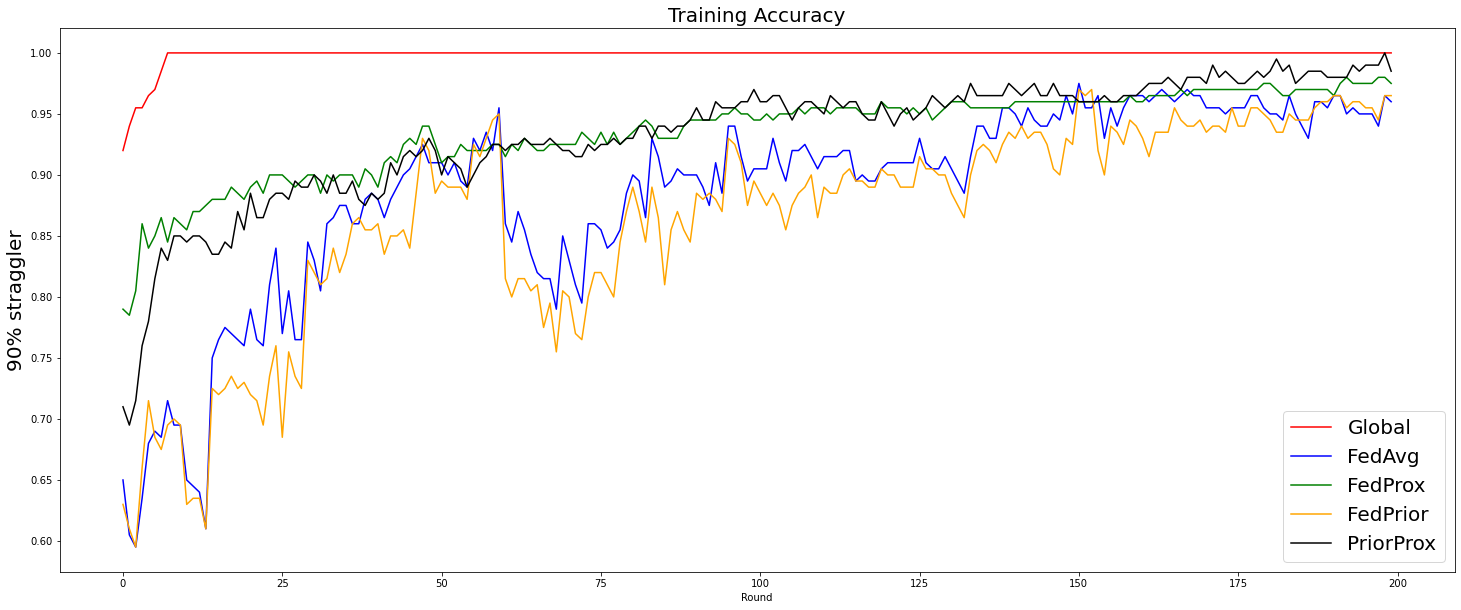

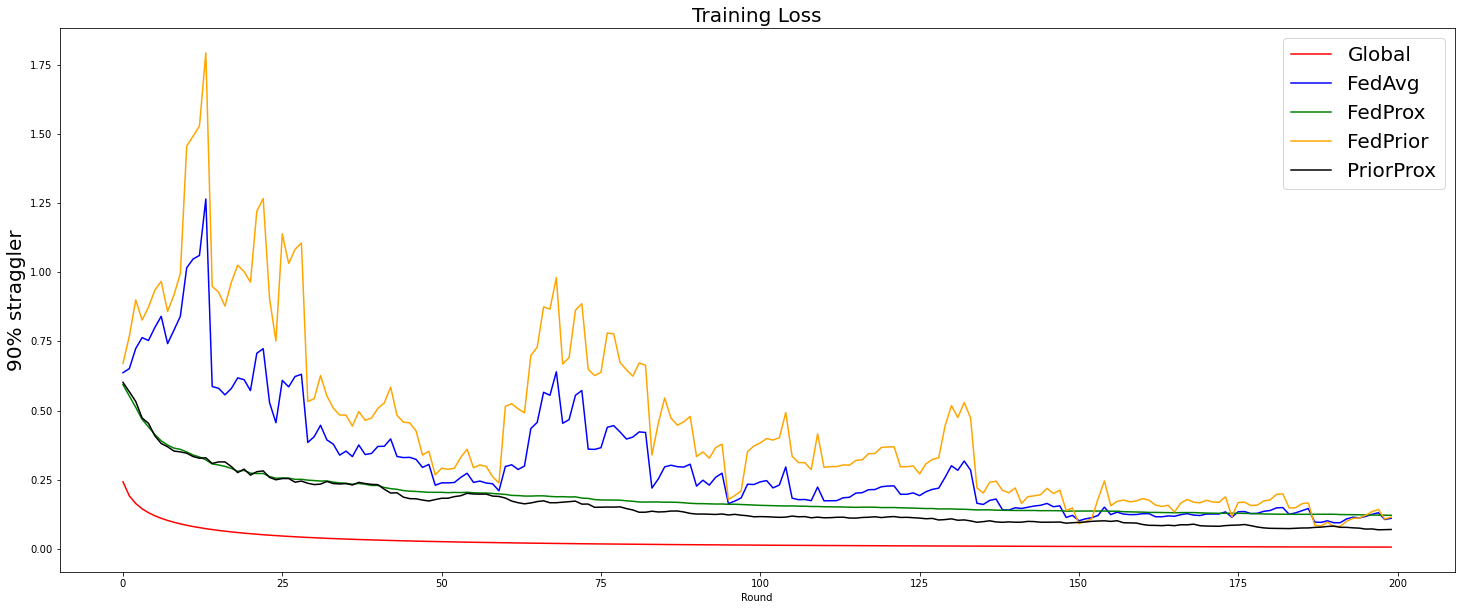

In [29]:
plt.figure(figsize=(25,10))
plt.plot(global_train,color='red')
plt.plot(avg_train_9,color='blue')
plt.plot(prox_train_9,color='green')
plt.plot(prior_train_9,color='orange')
plt.plot(pp_train_9,color='black')
plt.xlabel('Round')
plt.ylabel('90% straggler',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))

plt.plot(np.squeeze(loss0),color='red')
plt.plot(np.squeeze(loss1_9),color='blue')
plt.plot(np.squeeze(loss2_9),color='green')
plt.plot(np.squeeze(loss3_9),color='orange')
plt.plot(np.squeeze(loss4_9),color='black')
plt.xlabel('Round')
plt.ylabel('90% straggler',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

# Figure2

## iid

In [30]:

straggler_rate=0.5

#产生数据
np.random.seed(666)#固定wk,test_x,test_y
wk=create_wk(alpha,dim)
cov_1=np.identity(dim)
Bk=np.squeeze(np.random.normal(loc =0 , scale= beta,size = (1,dim)))
vk=np.squeeze(np.random.multivariate_normal(Bk, cov_1, (1,), 'raise'))

test_x,test_y=iid(wk,beta,dim,200,vk)
client_list=[]
for i in range(0,clients_num):
    np.random.seed(i)
    x1,y1=iid(wk,beta,dim,20,vk)
    client1=Client(x1,y1)
    client_list.append(client1)
    
x_global=client_list[0].x
y_global=client_list[0].y
for i in range(1,clients_num):
    x_global=np.vstack((x_global,client_list[i].x))
    y_global=np.vstack((y_global,client_list[i].y))

global_w_iid,global_train_iid,global_test_iid,loss0_iid=Global(rounds,x_global,y_global,batchsize)
avg_w_iid,avg_train_iid,avg_test_iid,loss1_iid=FedAvg(rounds,client_list,dim,batchsize)
prox_w_iid,prox_train_iid,prox_test_iid,loss2_iid=FedProx(rounds,client_list,dim,batchsize)
prior_w_iid,prior_train_iid,prior_test_iid,loss3_iid=FedPrior(rounds,client_list,dim,0.1,batchsize)
pp_w_iid,pp_train_iid,pp_test_iid,loss4_iid=PriorProx(rounds,client_list,dim,0.1,batchsize)


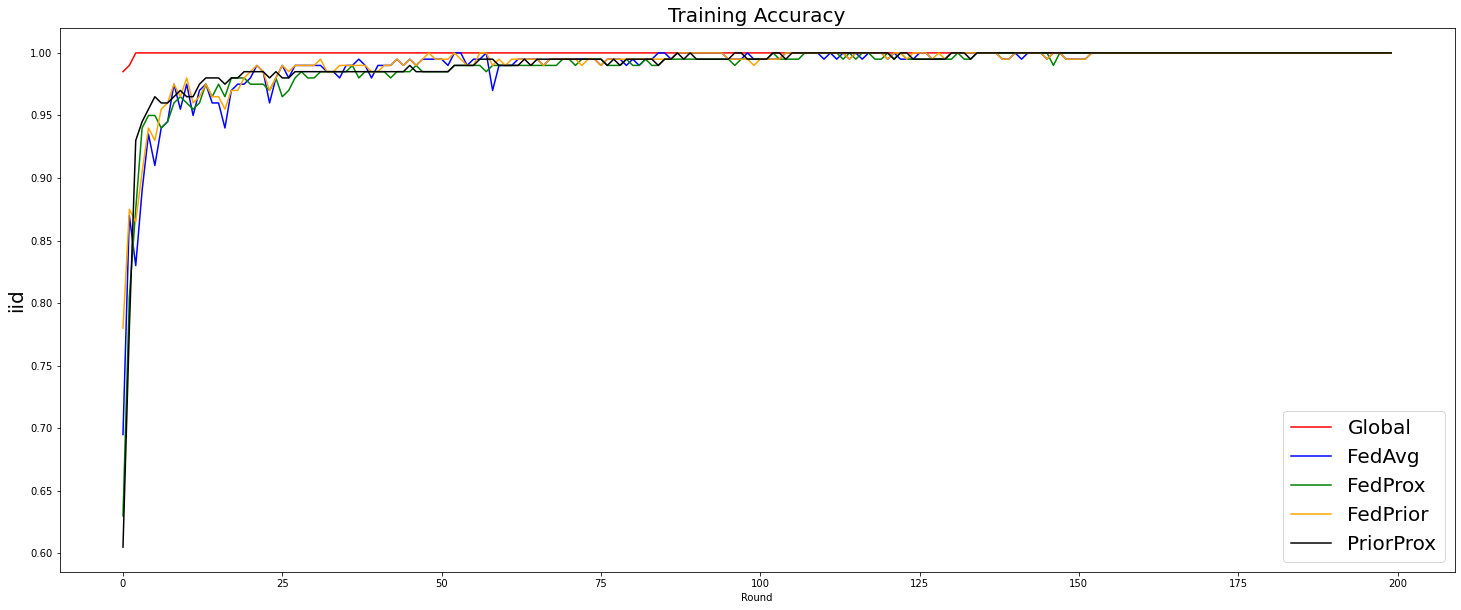

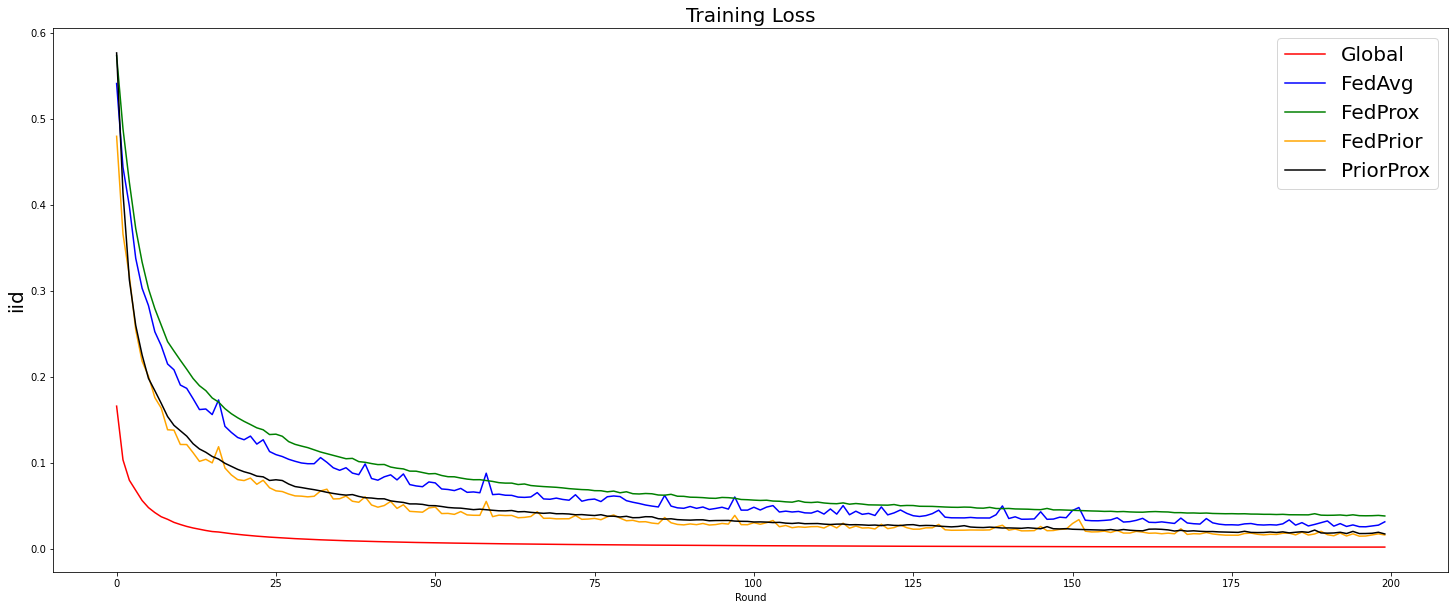

In [31]:
plt.figure(figsize=(25,10))
plt.plot(global_train_iid,color='red')
plt.plot(avg_train_iid,color='blue')
plt.plot(prox_train_iid,color='green')
plt.plot(prior_train_iid,color='orange')
plt.plot(pp_train_iid,color='black')
plt.xlabel('Round')
plt.ylabel('iid',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)

plt.figure(figsize=(25,10))

plt.plot(np.squeeze(loss0_iid),color='red')
plt.plot(np.squeeze(loss1_iid),color='blue')
plt.plot(np.squeeze(loss2_iid),color='green')
plt.plot(np.squeeze(loss3_iid),color='orange')
plt.plot(np.squeeze(loss4_iid),color='black')
plt.xlabel('Round')
plt.ylabel('iid',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)

## sythetic(0.5,0.5)

In [32]:

beta=0.5
alpha=0.5


#产生数据
np.random.seed(666)#固定wk,test_x,test_y
#wk=create_wk(alpha,dim)
test_x,test_y=multdata(alpha,beta,dim,200)
client_list=[]
for i in range(0,clients_num):
    np.random.seed(i)
    x1,y1=multdata(alpha,beta,dim,20)
    client1=Client(x1,y1)
    client_list.append(client1)
    
x_global=client_list[0].x
y_global=client_list[0].y
for i in range(1,clients_num):
    x_global=np.vstack((x_global,client_list[i].x))
    y_global=np.vstack((y_global,client_list[i].y))

global_w_0505,global_train_0505,global_test_0505,loss0_0505=Global(rounds,x_global,y_global,batchsize)
avg_w_0505,avg_train_0505,avg_test_0505,loss1_0505=FedAvg(rounds,client_list,dim,batchsize)
prox_w_0505,prox_train_0505,prox_test_0505,loss2_0505=FedProx(rounds,client_list,dim,batchsize)
prior_w_0505,prior_train_0505,prior_test_0505,loss3_0505=FedPrior(rounds,client_list,dim,0.1,batchsize)
pp_w_0505,pp_train_0505,pp_test_0505,loss4_0505=PriorProx(rounds,client_list,dim,0.1,batchsize)

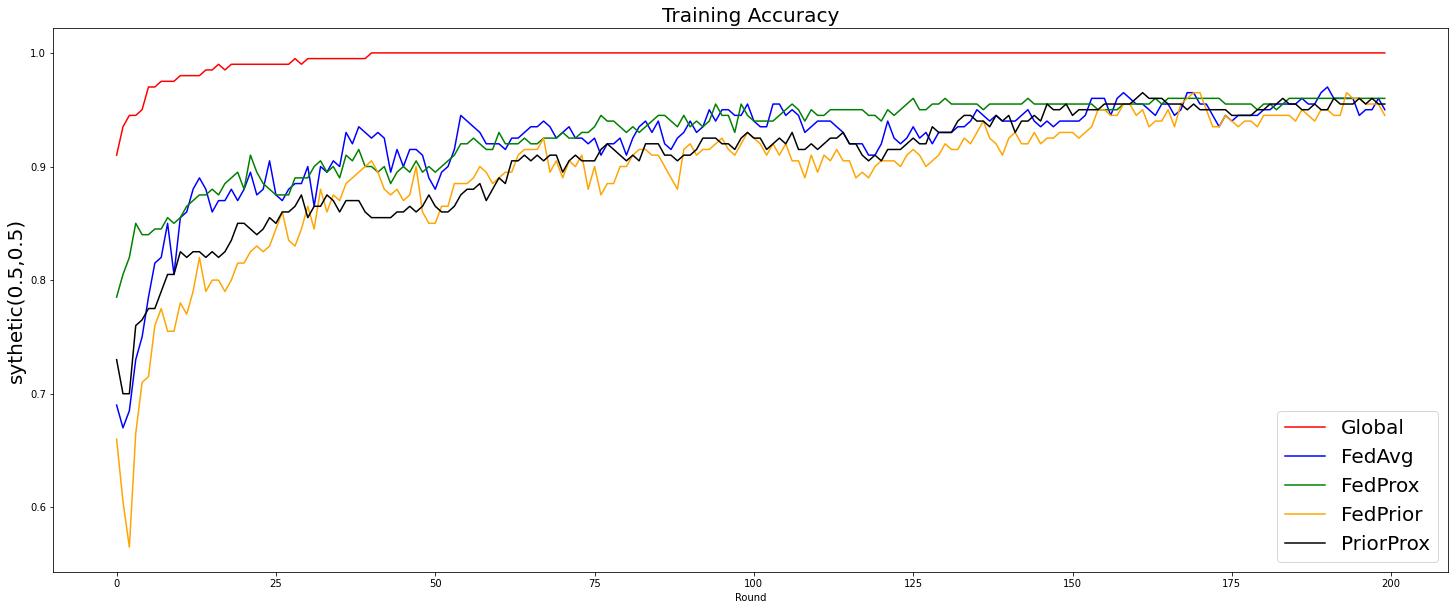

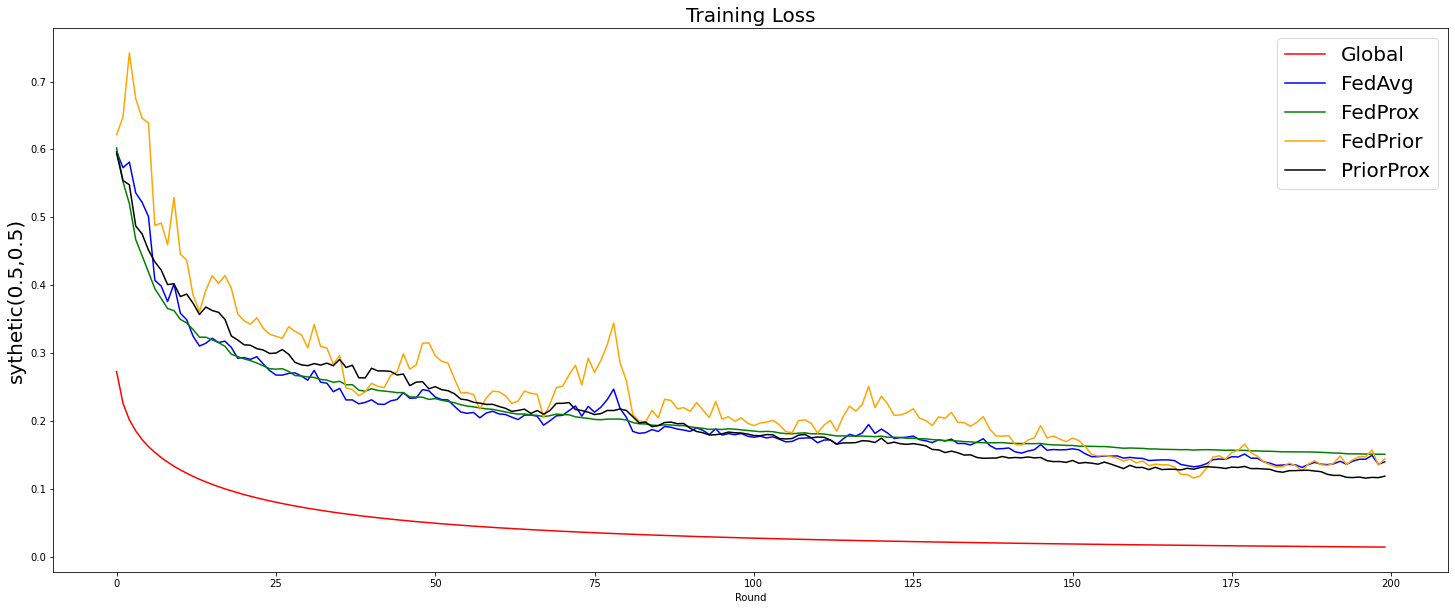

In [33]:
plt.figure(figsize=(25,10))
plt.plot(global_train_0505,color='red')
plt.plot(avg_train_0505,color='blue')
plt.plot(prox_train_0505,color='green')
plt.plot(prior_train_0505,color='orange')
plt.plot(pp_train_0505,color='black')
plt.xlabel('Round')
plt.ylabel('sythetic(0.5,0.5)',fontsize=20)
plt.title('Training Accuracy',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="lower right",fontsize=20)
plt.show()

plt.figure(figsize=(25,10))
#plt.ylim((-0.1,0.5))
plt.plot(np.squeeze(loss0_0505),color='red')
plt.plot(np.squeeze(loss1_0505),color='blue')
plt.plot(np.squeeze(loss2_0505),color='green')
plt.plot(np.squeeze(loss3_0505),color='orange')
plt.plot(np.squeeze(loss4_0505),color='black')
plt.xlabel('Round')
plt.ylabel('sythetic(0.5,0.5)',fontsize=20)
plt.title('Training Loss',fontsize=20)
plt.legend(labels=['Global','FedAvg','FedProx','FedPrior','PriorProx'],loc="upper right",fontsize=20)
plt.show()